In [ ]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from sentence_transformers import SentenceTransformer
import json

def encode_sentences(in_file, out_file):
    model = SentenceTransformer('sentence-transformers/distiluse-base-multilingual-cased-v1')

    with open(in_file, 'r', encoding='utf-8') as f:
        corpus = json.load(f)

    all_sentences = []
    mapping = []

    for chapter_id, sentences in corpus.items():
        for i, sentence in enumerate(sentences):
            line = sentence['sentence']
            if line.strip():
                all_sentences.append(line)
                mapping.append((chapter_id, i))

    embeddings = model.encode(all_sentences, show_progress_bar=True)

    for (chapter_id, i), emb in zip(mapping, embeddings):
        corpus[chapter_id][i]["embedding"] = emb.tolist()

    with open(out_file, 'w', encoding='utf-8') as f:
        json.dump(corpus, f, ensure_ascii=False, indent=4)

encode_sentences('corpus_cooccurence.json', 'corpus_cooccurence_with_embeddings.json')
encode_sentences('corpus_religion.json', 'corpus_religion_with_embeddings.json')
encode_sentences('corpus_ner.json', 'corpus_ner_with_embeddings.json')

Batches: 100%|██████████| 129/129 [00:03<00:00, 38.12it/s]


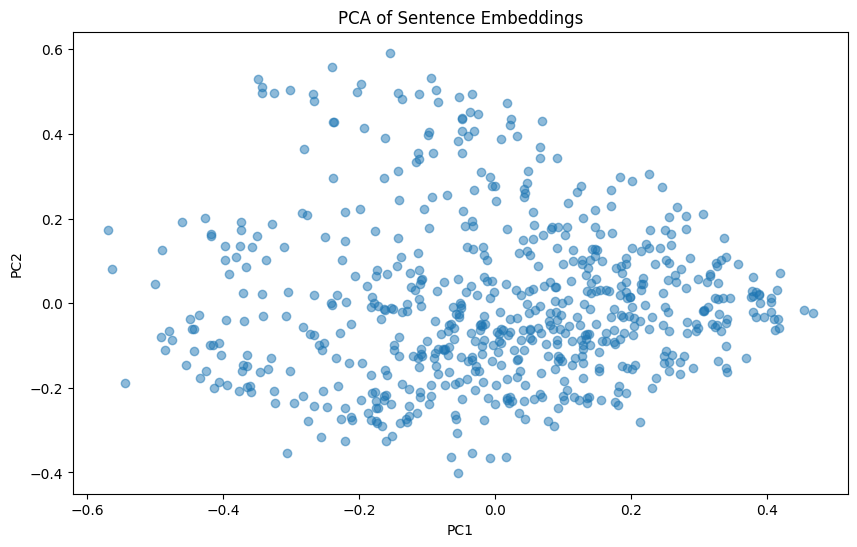

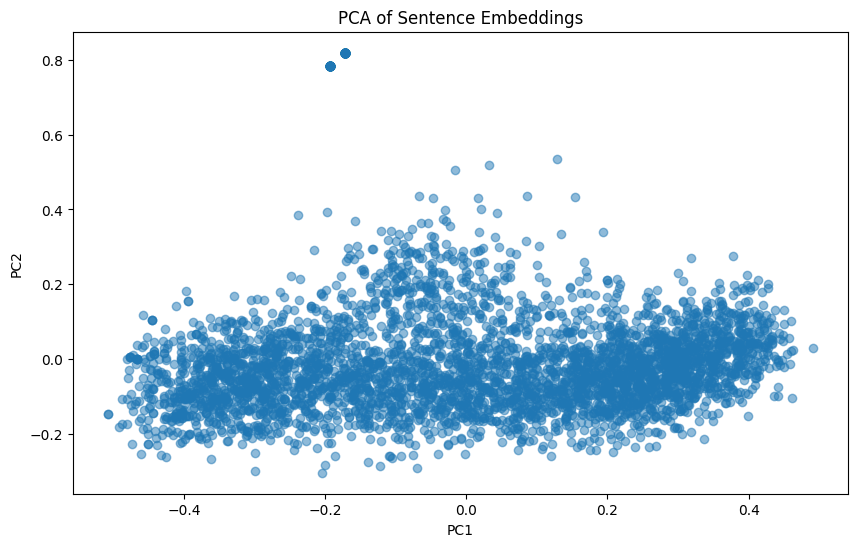

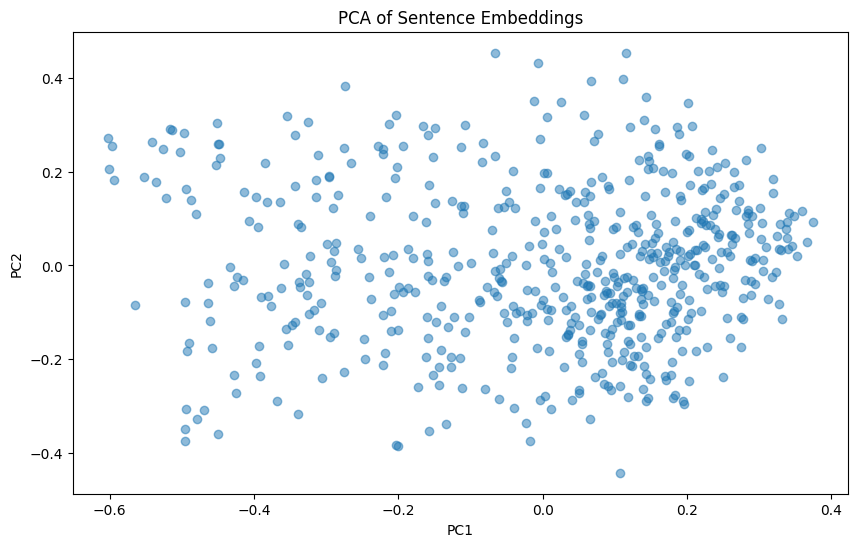

In [2]:
import json
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def load_corpus_with_embeddings(file):
    with open(file, 'r', encoding='utf-8') as f:
        corpus = json.load(f)

    embeddings = []
    texts = []
    for chapter_id, sentences in corpus.items():
        for sentence in sentences:
            emb = sentence.get("embedding")
            if emb is not None:
                embeddings.append(emb)
                texts.append(sentence["sentence"])

    embeddings = np.array(embeddings)
    return texts, embeddings

def pca(embeddings):
    pca_model = PCA(n_components=2)
    reduced = pca_model.fit_transform(embeddings)

    plt.figure(figsize=(10, 6))
    plt.scatter(reduced[:, 0], reduced[:, 1], alpha=0.5)

    plt.title("PCA of Sentence Embeddings")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    plt.show()

    return reduced

texts, embeddings = load_corpus_with_embeddings('corpus_cooccurence_with_embeddings.json')
reduced_embeddings = pca(embeddings)

texts_all, embeddings_all = load_corpus_with_embeddings('corpus_ner_with_embeddings.json')
reduced_embeddings_all = pca(embeddings_all)

texts_religion, embeddings_religion = load_corpus_with_embeddings('corpus_religion_with_embeddings.json')
reduced_embeddings_religion = pca(embeddings_religion)

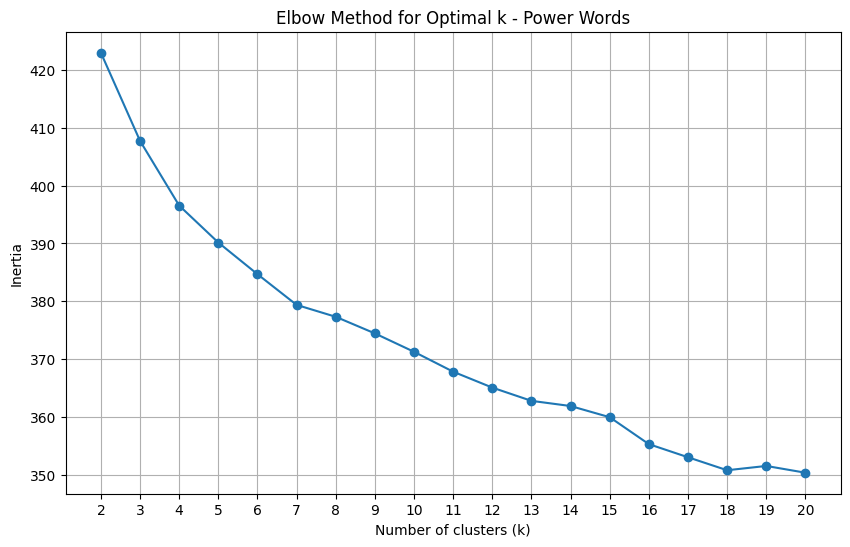

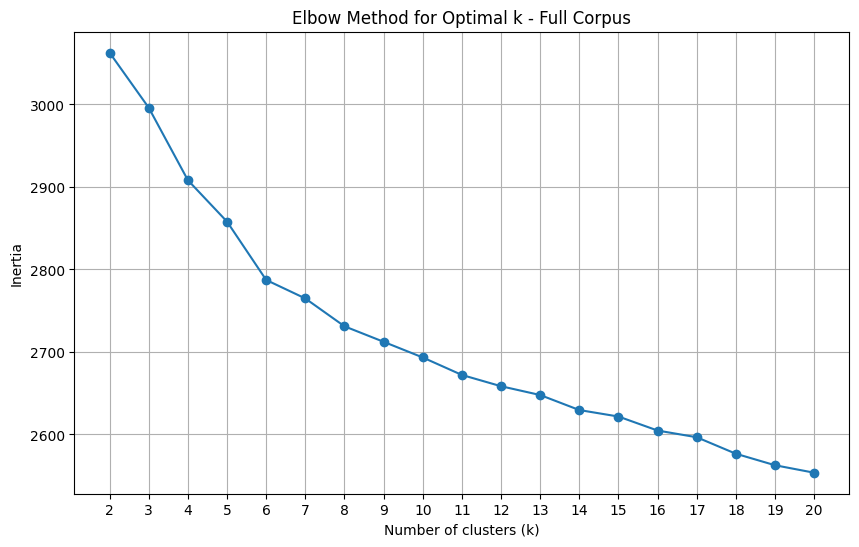

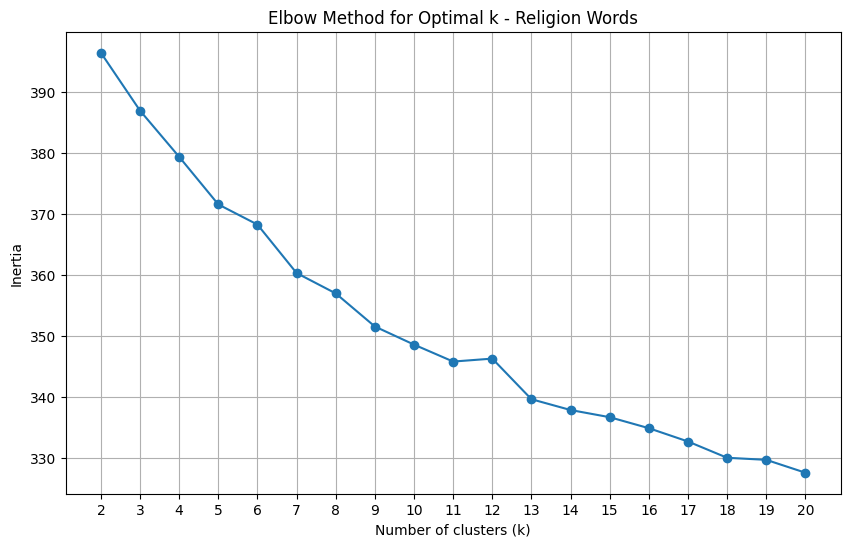

In [ ]:
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def elbow_method(embeddings, title, max_k=20):
    embeddings = normalize(embeddings)
    intertias = []

    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(embeddings)
        intertias.append(kmeans.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_k + 1), intertias, marker='o')
    plt.title(f"Elbow Method for Optimal k - {title}")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Inertia")
    plt.xticks(range(2, max_k + 1))
    plt.grid()
    plt.savefig(f"BERT_images/elbow_method_{title.replace(' ', '_').lower()}.png", dpi=500)
    plt.show()

elbow_method(embeddings, "Power Words")
elbow_method(embeddings_all, "Full Corpus")
elbow_method(embeddings_religion, "Religion Words")

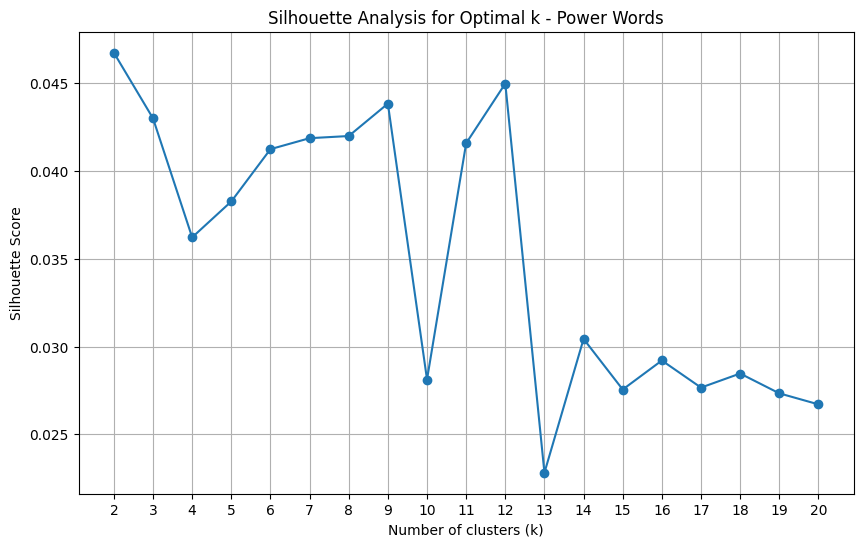

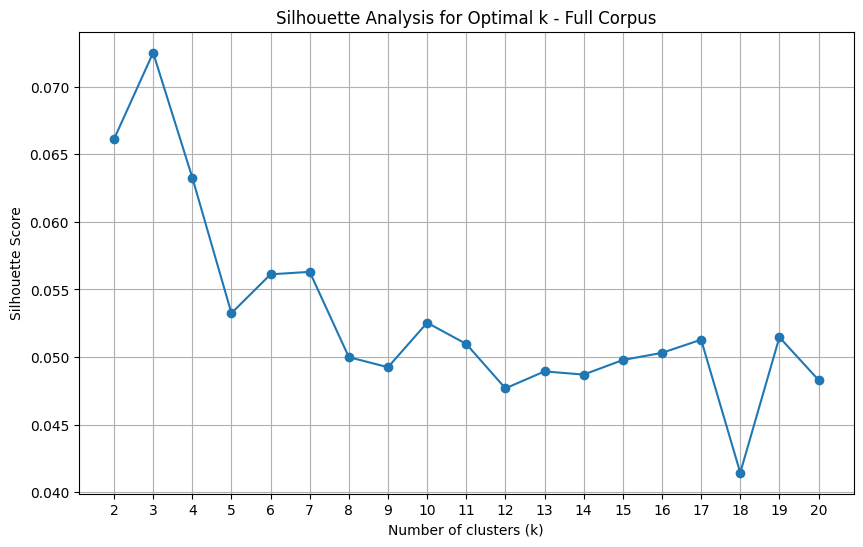

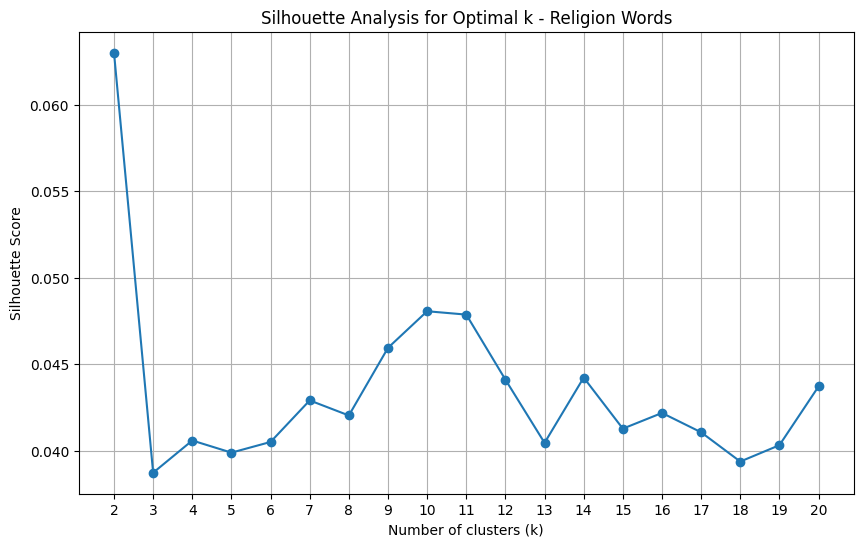

In [5]:
from sklearn.metrics import silhouette_score

def silhouette_analysis(embeddings, title, max_k=20):
    embeddings = normalize(embeddings)
    silhouette_scores = []

    for k in range(2, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)
        silhouette_scores.append(score)

    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_k + 1), silhouette_scores, marker='o')
    plt.title(f"Silhouette Analysis for Optimal k - {title}")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.xticks(range(2, max_k + 1))
    plt.grid()
    plt.savefig(f"BERT_images/silhouette_analysis_{title.replace(' ', '_').lower()}.png", dpi=500)
    plt.show()

silhouette_analysis(embeddings, "Power Words")
silhouette_analysis(embeddings_all, "Full Corpus")
silhouette_analysis(embeddings_religion, "Religion Words")

In [6]:
import json
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

def cluster_sentences(in_file, out_file, k=2):
    with open(in_file, 'r', encoding='utf-8') as f:
        corpus = json.load(f)

    embeddings = []
    mapping = []

    for chapter_id, sentences in corpus.items():
        for i, sentence in enumerate(sentences):
            emb = sentence.get("embedding")
            if emb is not None:
                embeddings.append(emb)
                mapping.append((chapter_id, i))

    embeddings = np.array(embeddings)
    embeddings = normalize(embeddings)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(embeddings)

    for (chapter_id, i), label in zip(mapping, labels):
        corpus[chapter_id][i]["cluster"] = int(label)

    with open(out_file, 'w', encoding='utf-8') as f:
        json.dump(corpus, f, ensure_ascii=False, indent=4)


cluster_sentences(in_file='corpus_cooccurence_with_embeddings.json', out_file='corpus_with_clusters_k2.json', k=2)
cluster_sentences(in_file='corpus_religion_with_embeddings.json', out_file='corpus_religion_with_clusters_k2.json', k=2)
cluster_sentences(in_file='corpus_ner_with_embeddings.json', out_file='corpus_all_with_clusters_k2.json', k=2)
cluster_sentences(in_file='corpus_ner_with_embeddings.json', out_file='corpus_all_with_clusters_k3.json', k=3)

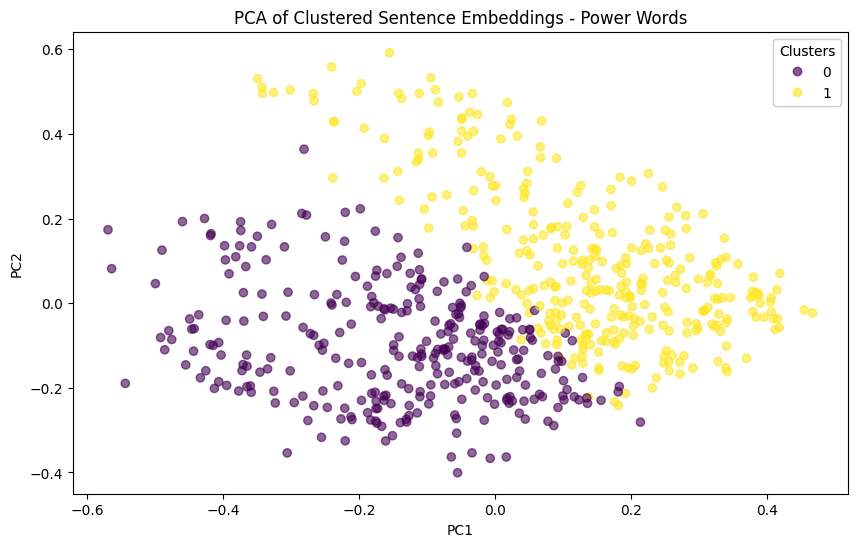

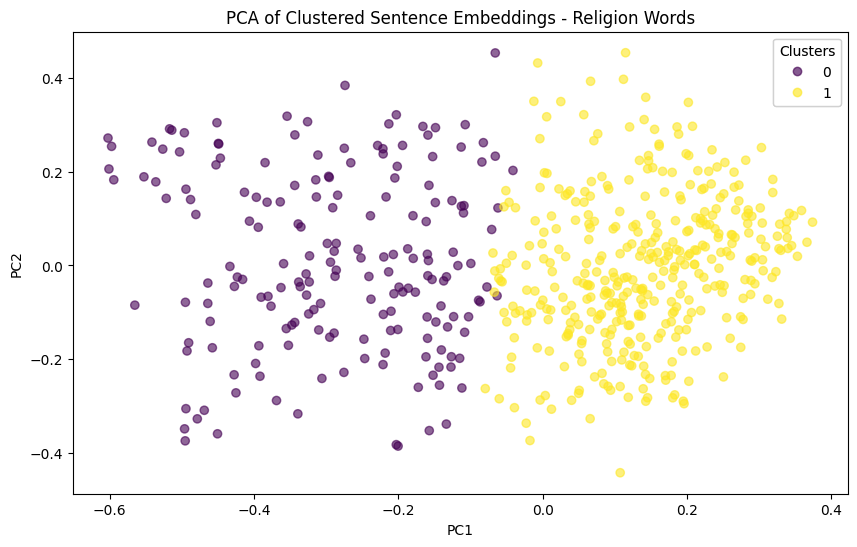

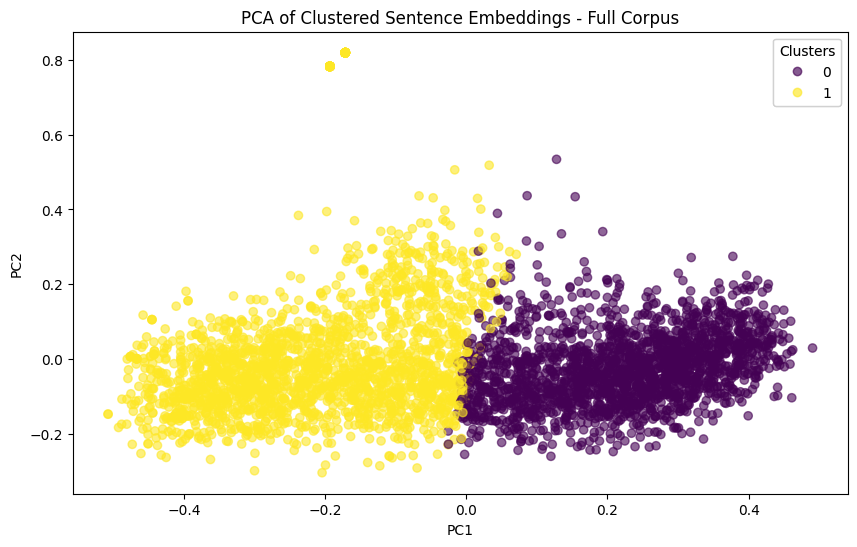

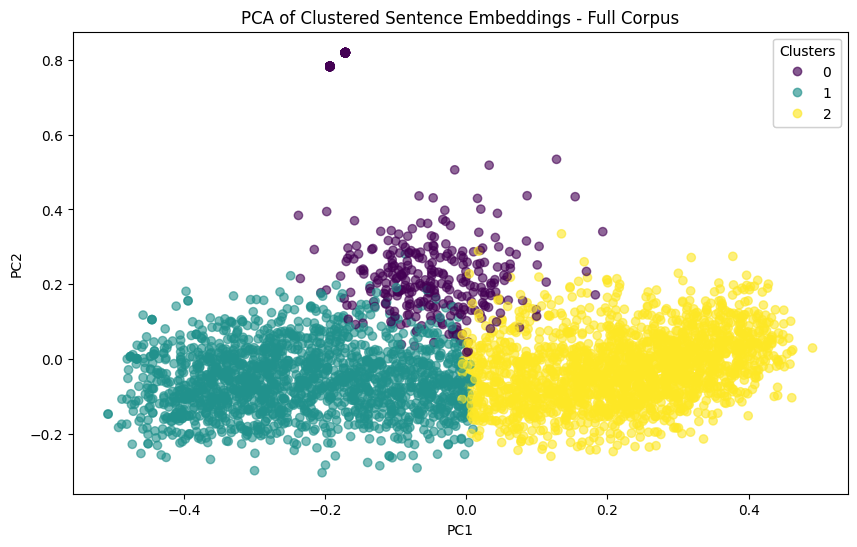

In [7]:
import json
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_pca(in_file, title):
    with open(in_file, 'r', encoding='utf-8') as f:
        corpus = json.load(f)

    embeddings = []
    clusters = []

    for chapter_id, sentences in corpus.items():
        for sentence in sentences:
            emb = sentence.get("embedding")
            label = sentence.get("cluster")

            if emb is not None and label is not None:
                embeddings.append(emb)
                clusters.append(label)

    embeddings = np.array(embeddings)

    pca = PCA(n_components=2)
    reduced = pca.fit_transform(embeddings)
    plt.figure(figsize=(10,6))
    scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=clusters, alpha=0.6)
    plt.title(f"PCA of Clustered Sentence Embeddings - {title}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")

    legend = plt.legend(*scatter.legend_elements(), title="Clusters")
    plt.gca().add_artist(legend)
    plt.savefig(f"BERT_images/pca_{title.replace(' ', '_').lower()}_k_{len(set(clusters))}.png", dpi=500)
    plt.show()

plot_pca('corpus_with_clusters_k2.json', 'Power Words')
plot_pca('corpus_religion_with_clusters_k2.json', 'Religion Words')
plot_pca('corpus_all_with_clusters_k2.json', 'Full Corpus')
plot_pca('corpus_all_with_clusters_k3.json', 'Full Corpus')

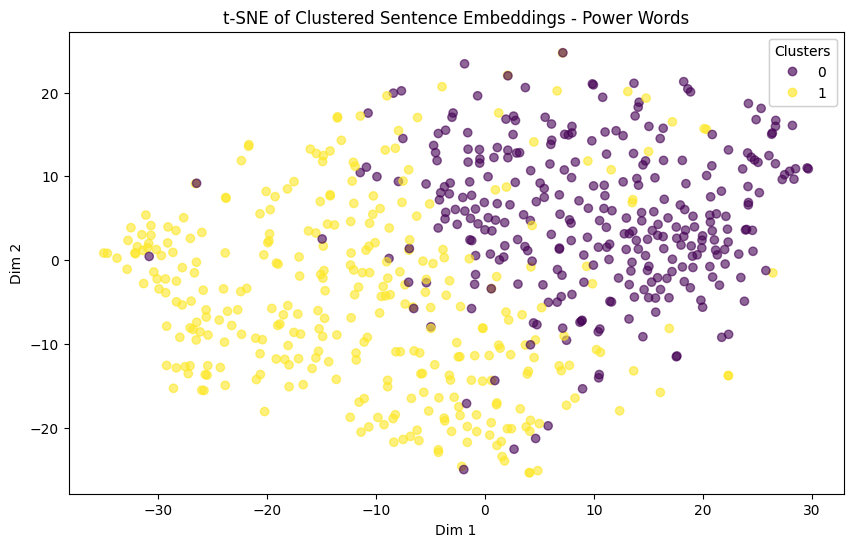

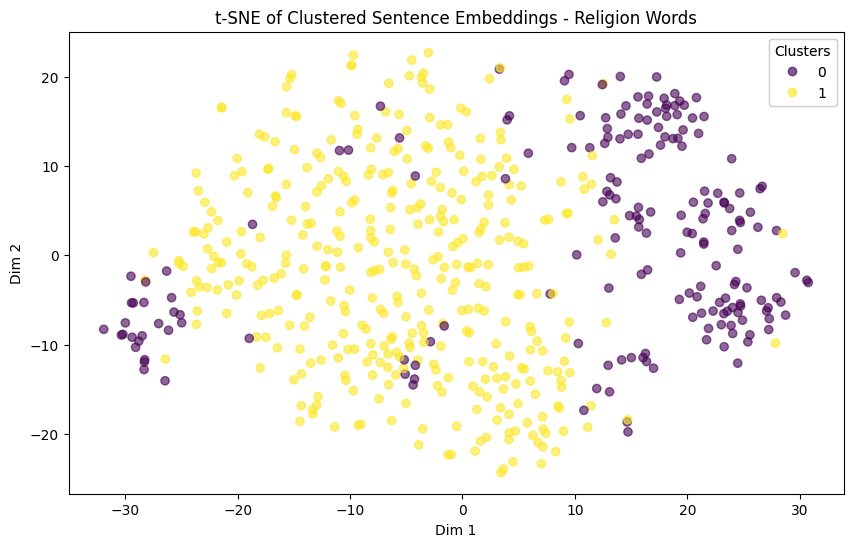

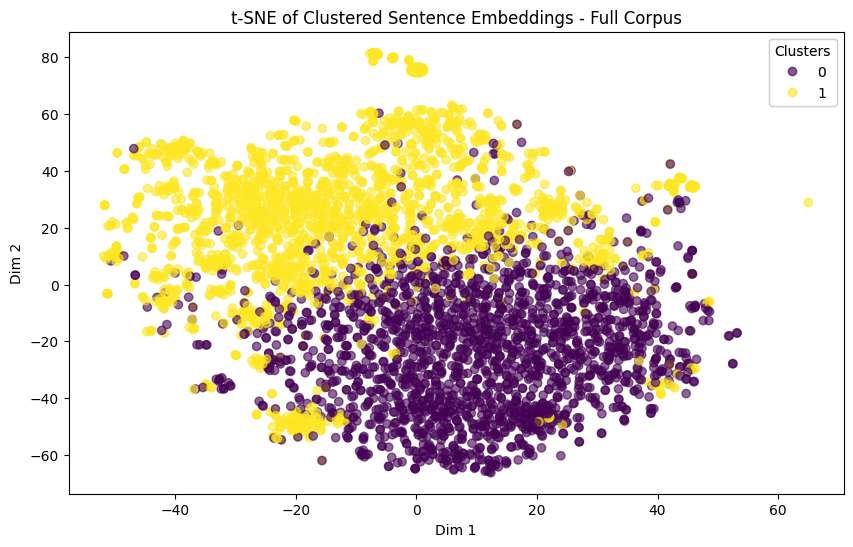

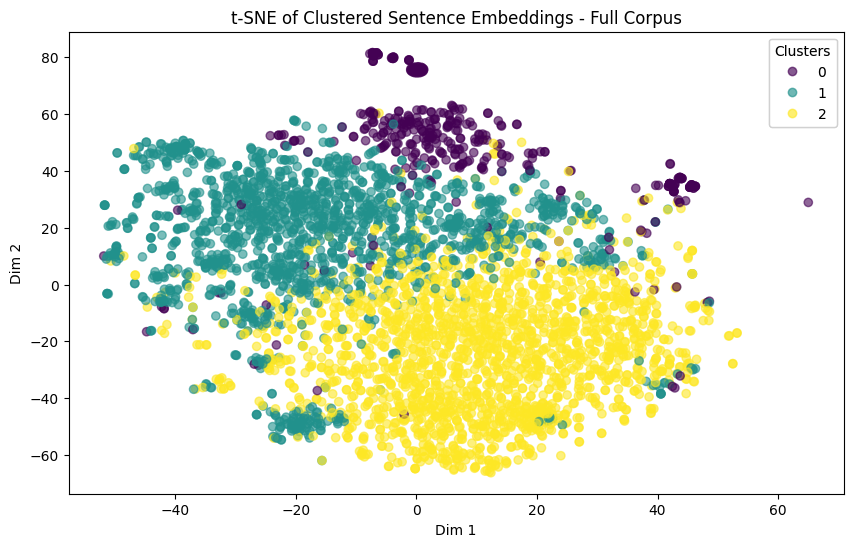

In [8]:
from sklearn.manifold import TSNE

def plot_tsne(in_file, title):
    with open(in_file, 'r', encoding='utf-8') as f:
        corpus = json.load(f)

    embeddings = []
    clusters = []

    for chapter_id, sentences in corpus.items():
        for sentence in sentences:
            emb = sentence.get("embedding")
            label = sentence.get("cluster")

            if emb is not None and label is not None:
                embeddings.append(emb)
                clusters.append(label)

    embeddings = np.array(embeddings)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    reduced = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10,6))
    scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=clusters, alpha=0.6)

    plt.title(f"t-SNE of Clustered Sentence Embeddings - {title}")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")

    legend = plt.legend(*scatter.legend_elements(), title="Clusters")
    plt.gca().add_artist(legend)

    plt.savefig(f"BERT_images/tsne_{title.replace(' ', '_').lower()}_k_{len(set(clusters))}.png", dpi=500)
    plt.show()

plot_tsne('corpus_with_clusters_k2.json', 'Power Words')
plot_tsne('corpus_religion_with_clusters_k2.json', 'Religion Words')
plot_tsne('corpus_all_with_clusters_k2.json', 'Full Corpus')
plot_tsne('corpus_all_with_clusters_k3.json', 'Full Corpus')

c:\Spring 2026\IDS570\IDS570_Text_as_Data\Final_Project\arabiyya\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Spring 2026\IDS570\IDS570_Text_as_Data\Final_Project\arabiyya\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


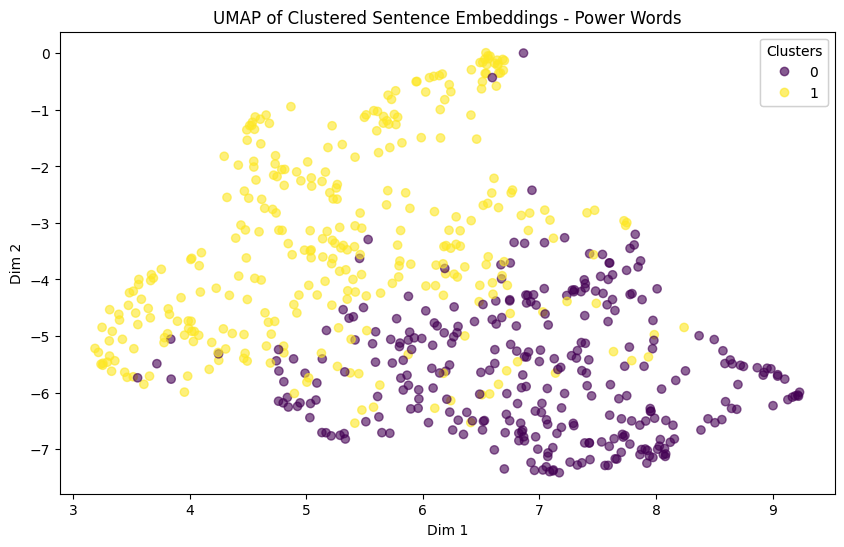

c:\Spring 2026\IDS570\IDS570_Text_as_Data\Final_Project\arabiyya\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


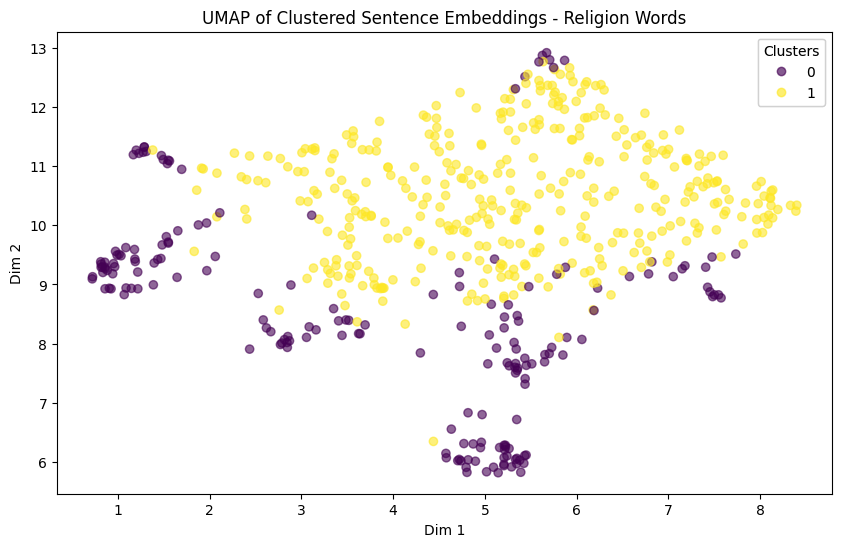

c:\Spring 2026\IDS570\IDS570_Text_as_Data\Final_Project\arabiyya\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


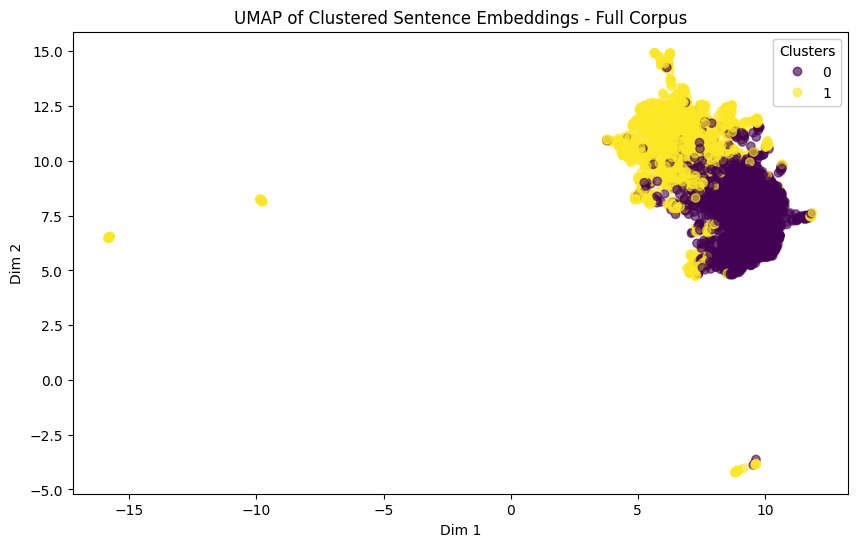

c:\Spring 2026\IDS570\IDS570_Text_as_Data\Final_Project\arabiyya\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


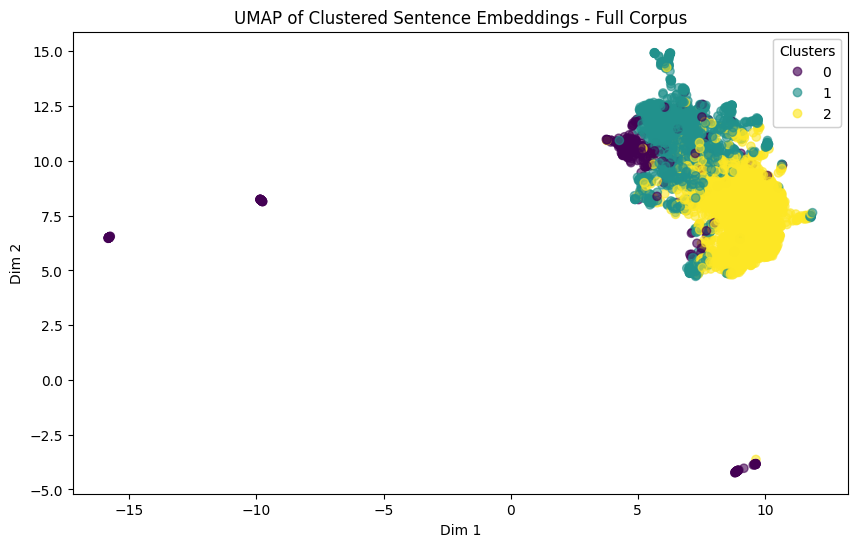

In [9]:
import umap

def plot_umap(in_file, title):
    with open(in_file, 'r', encoding='utf-8') as f:
        corpus = json.load(f)

    embeddings = []
    clusters = []

    for chapter_id, sentences in corpus.items():
        for sentence in sentences:
            emb = sentence.get("embedding")
            label = sentence.get("cluster")

            if emb is not None and label is not None:
                embeddings.append(emb)
                clusters.append(label)

    embeddings = np.array(embeddings)

    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    reduced = reducer.fit_transform(embeddings)

    plt.figure(figsize=(10,6))
    scatter = plt.scatter(reduced[:, 0], reduced[:, 1], c=clusters, alpha=0.6)

    plt.title(f"UMAP of Clustered Sentence Embeddings - {title}")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")

    legend = plt.legend(*scatter.legend_elements(), title="Clusters")
    plt.gca().add_artist(legend)

    plt.savefig(f"BERT_images/umap_{title.replace(' ', '_').lower()}_k_{len(set(clusters))}.png", dpi=500)
    plt.show()

plot_umap('corpus_with_clusters_k2.json', 'Power Words')
plot_umap('corpus_religion_with_clusters_k2.json', 'Religion Words')
plot_umap('corpus_all_with_clusters_k2.json', 'Full Corpus')
plot_umap('corpus_all_with_clusters_k3.json', 'Full Corpus')

In [2]:
import json
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

def tfidf_clusters(in_file):
    with open(in_file, 'r', encoding='utf-8') as f:
        corpus = json.load(f)

    cluster_map = defaultdict(list)

    for chapter_id, sentences in corpus.items():
        for sentence in sentences:
            cluster = sentence.get("cluster")
            lemmas = sentence.get("lemmas")
            if cluster is not None and lemmas is not None:
                cluster_map[cluster].extend(lemmas)

    cluster_ids = list(cluster_map.keys())
    docs = [' '.join(cluster_map[cluster]) for cluster in cluster_ids]

    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(docs)

    tfidf_df = pd.DataFrame(
        tfidf_matrix.toarray(),
        columns=vectorizer.get_feature_names_out(),
        index=cluster_ids
    )
    return tfidf_df

def get_top_tfidf_words(tfidf_df, top_n=20):
    top_words = {}
    for doc in tfidf_df.index:
        top_terms = (tfidf_df.loc[doc].sort_values(ascending=False).head(top_n).index.tolist())
        top_words[doc] = top_terms
    return top_words

def print_top_tfidf_words(top_words, tfidf_df):
    for doc, words in top_words.items():
        print(f"Document: {doc}")
        for word in words:
            print(f"Score: {tfidf_df.loc[doc, word]:.4f} - Word: {word}")
        print()

print("Top TF-IDF words for Power Corpus:")
tfidf_df_power = tfidf_clusters('corpus_with_clusters_k2.json')
top_words_power = get_top_tfidf_words(tfidf_df_power)
print_top_tfidf_words(top_words_power, tfidf_df_power)

print("Top TF-IDF words for Religion Corpus:")
tfidf_df_religion = tfidf_clusters('corpus_religion_with_clusters_k2.json')
top_words_religion = get_top_tfidf_words(tfidf_df_religion)
print_top_tfidf_words(top_words_religion, tfidf_df_religion)

# print("Top TF-IDF words for All Corpus (k=2):")
# tfidf_df_all_k2 = tfidf_clusters('corpus_all_with_clusters_k2.json')
# top_words_all_k2 = get_top_tfidf_words(tfidf_df_all_k2)
# print_top_tfidf_words(top_words_all_k2, tfidf_df_all_k2)

print("Top TF-IDF words for All Corpus (k=3):")
tfidf_df_all_k3 = tfidf_clusters('corpus_all_with_clusters_k3.json')
top_words_all_k3 = get_top_tfidf_words(tfidf_df_all_k3)
print_top_tfidf_words(top_words_all_k3, tfidf_df_all_k3)

Top TF-IDF words for Power Corpus:
Document: 0
Score: 0.5862 - Word: قال
Score: 0.4005 - Word: ملك
Score: 0.3113 - Word: الملك
Score: 0.1908 - Word: فلما
Score: 0.1619 - Word: ليلة
Score: 0.1594 - Word: السعيد
Score: 0.1569 - Word: بلغني
Score: 0.1544 - Word: وزير
Score: 0.1268 - Word: أمر
Score: 0.1067 - Word: مكان
Score: 0.0967 - Word: عمر
Score: 0.0967 - Word: دخل
Score: 0.0967 - Word: يوم
Score: 0.0929 - Word: شركان
Score: 0.0803 - Word: النعمان
Score: 0.0803 - Word: الله
Score: 0.0741 - Word: زمان
Score: 0.0653 - Word: سمع
Score: 0.0640 - Word: يد
Score: 0.0640 - Word: أرض

Document: 1
Score: 0.4968 - Word: قال
Score: 0.2309 - Word: أمر
Score: 0.2021 - Word: يوم
Score: 0.1869 - Word: أمير
Score: 0.1854 - Word: وزير
Score: 0.1793 - Word: ملك
Score: 0.1626 - Word: خليفة
Score: 0.1489 - Word: سلطان
Score: 0.1459 - Word: عسكر
Score: 0.1398 - Word: مكان
Score: 0.1337 - Word: مؤمن
Score: 0.1215 - Word: شركان
Score: 0.1185 - Word: الله
Score: 0.1170 - Word: مسلم
Score: 0.1109 - Word: جعف